**DECHECTION, ANALYSE PRELIMINAIRE:**

In [ ]:
# Monter le Google Drive (c'est ici le dataset se trouve)

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Importation et vue globale du data

import os
import pandas as pd
import numpy as np

archive_path = "/content/drive/MyDrive/archive"
csv_path = os.path.join(archive_path, "meta_df.csv")
data_path = os.path.join(archive_path, "data")
df = pd.read_csv(csv_path)

print("Vue globale du data csv:")
print(f"\nStructure: {df.shape}")
print(f"\nColonnes: {list(df.columns)}\n")
print(df.head(3))

Vue globale du data csv:

Structure: (4784, 13)

Colonnes: ['img_id', 'img_width', 'img_height', 'img_file', 'cat_id', 'cat_name', 'supercategory', 'ann_id', 'x', 'y', 'width', 'height', 'area']

   img_id  img_width  img_height            img_file  cat_id      cat_name  \
0       0       1537        2049  batch_1/000006.jpg       6  Glass bottle   
1       1       1537        2049  batch_1/000008.jpg      18   Meal carton   
2       1       1537        2049  batch_1/000008.jpg      14  Other carton   

  supercategory  ann_id      x      y   width  height       area  
0        Bottle       1  517.0  127.0   447.0  1322.0   403954.0  
1        Carton       2    1.0  457.0  1429.0  1519.0  1071259.5  
2        Carton       3  531.0  292.0  1006.0   672.0    99583.5  


Donc, le dataset contient 4784 data points ou annotations pour 1500 images (donc, des images peuvent avoir plusieurs dechets y compris dans une seule). Il y a 13 colonnes (features), qui decrivent laa taille d'image, la categorie et supercategorie des dechets, et les coordonnees du bounding box pour chaque dechet (en vrai, annotation).

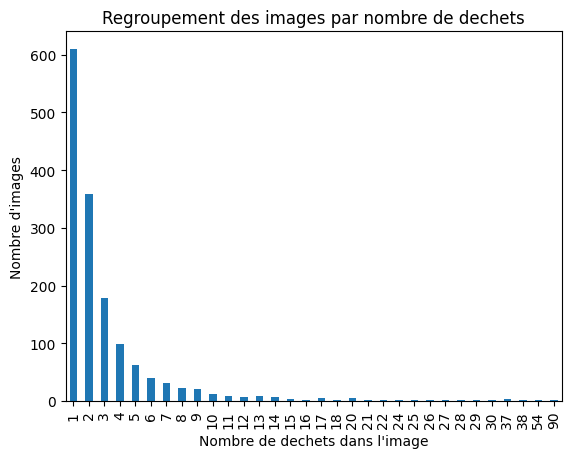

In [ ]:
# Regrouper le compte des images par le nombre de dechets y dedant

import matplotlib.pyplot as plt

objets_par_image = df.groupby("img_id").size()
image_counts_par_objet_count = objets_par_image.value_counts().sort_index()

image_counts_par_objet_count.plot(kind="bar") # Barplot
plt.xlabel("Nombre de dechets dans l'image")
plt.ylabel("Nombre d'images")
plt.title("Regroupement des images par nombre de dechets")
plt.show()

Donc, on peut dire que: par exemple, il y a presque 600 images qui ont un seul dechet objet, et 350 ont deux...etc, et ainsi de suite.

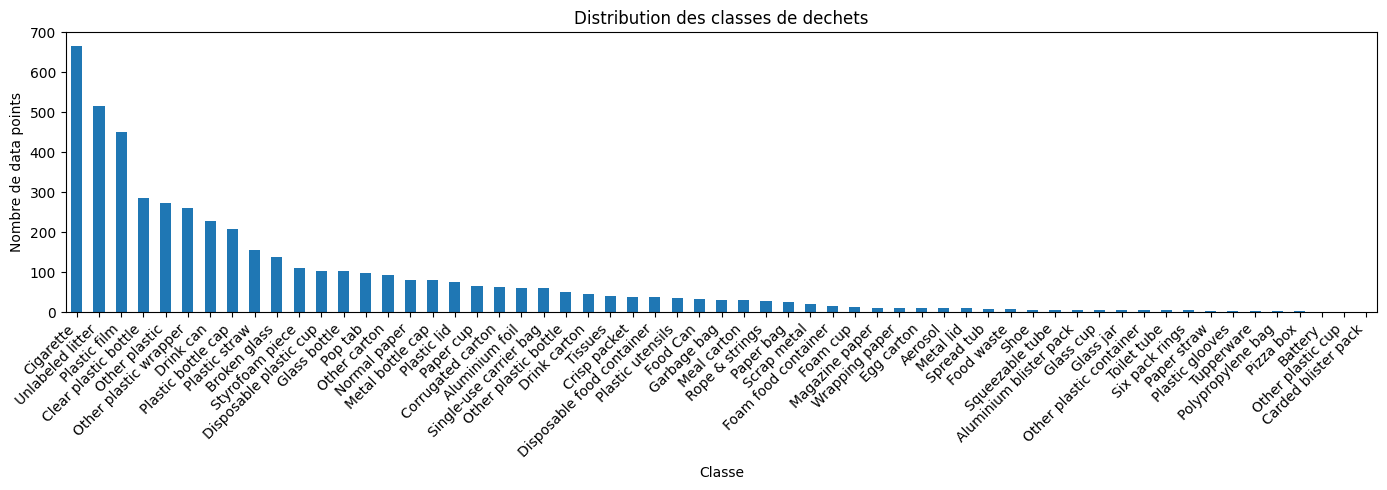

In [ ]:
# Regrouper les data entries par groupe de dechets

classe_counts = df["cat_name"].value_counts()

classe_counts.plot(kind="bar", figsize=(14, 5)) # Barplot
plt.xlabel("Classe")
plt.ylabel("Nombre de data points")
plt.title("Distribution des classes de dechets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Maintenant, on analyse le regroupement des dechets (les 4784) sur les 60 categories/classes. C'est pas reparti uniformement, par exemple, les cigarettes ont presque 670 data points mais Pop Tab approx 100, et memes quelques classes n'ont aucune annotation.

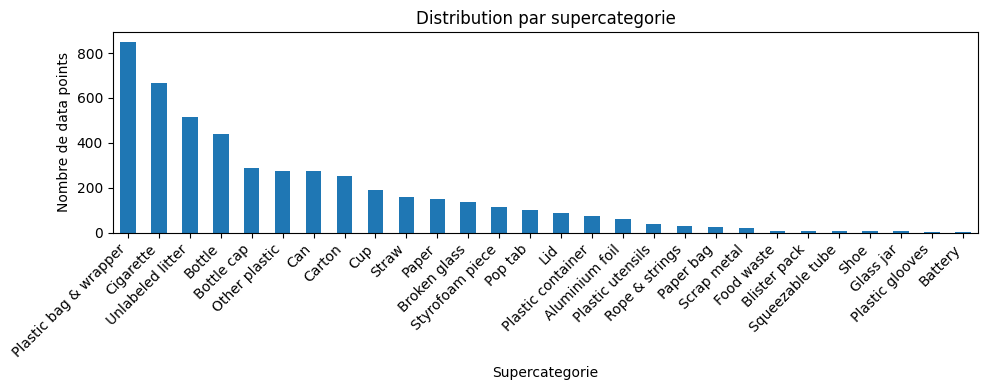

In [ ]:
# Regrouper les data entries par supercategorie

supercat_counts = df["supercategory"].value_counts()

supercat_counts.plot(kind="bar", figsize=(10, 4)) # Barplot
plt.xlabel("Supercategorie")
plt.ylabel("Nombre de data points")
plt.title("Distribution par supercategorie")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Aussi, il faut qu'on analyse similairement le regroupement des dechets (les 4784) sur les 28 supercategories/superclasses (des groupes de classes similaires). C'est pas reparti uniformement, par exemple, les Plastic Bag & Wrapper ont presque 820 data points mais Cup approx 200, et memes quelques classes ont presqu'aucune annotation.

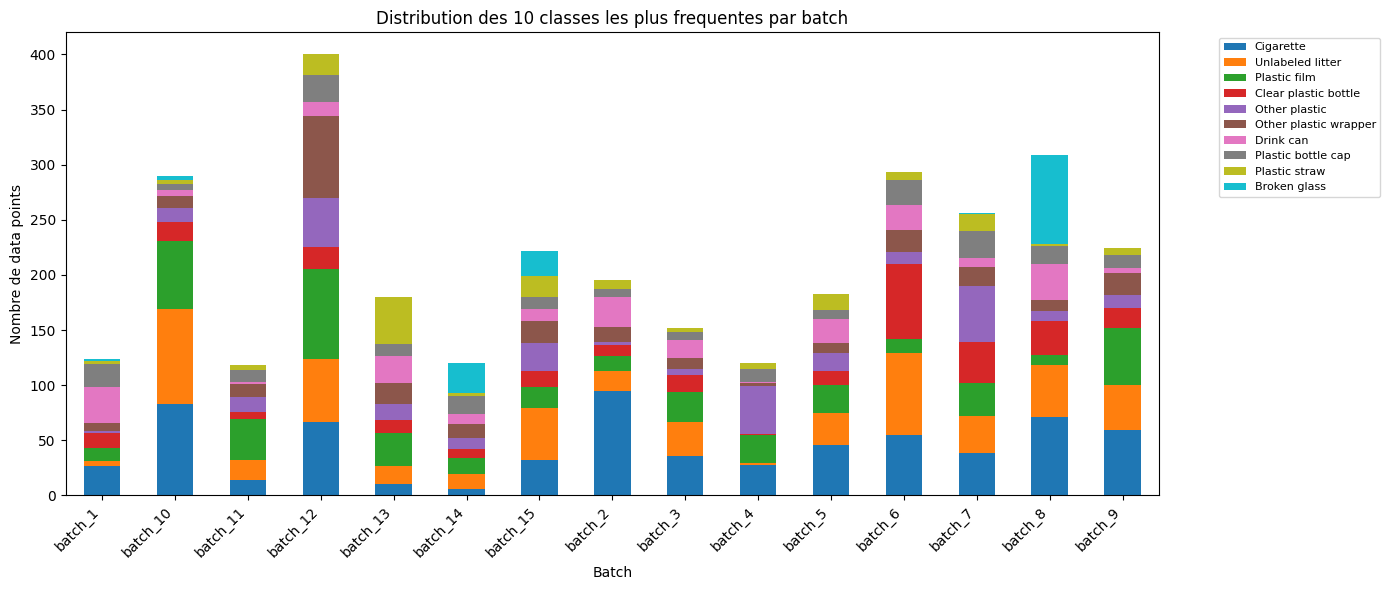

In [ ]:
# Distribution des classes par batch (les 10 classes les plus frequentes)

df["batch"] = df["img_file"].apply(lambda x: x.split("/")[0])
batch_classe = df.groupby(["batch", "cat_name"]).size().unstack(fill_value=0)

top10_classes = df["cat_name"].value_counts().head(10).index
batch_classe[top10_classes].plot(kind="bar", figsize=(14, 6), stacked=True)
plt.xlabel("Batch")
plt.ylabel("Nombre de data points")
plt.title("Distribution des 10 classes les plus frequentes par batch")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Ici, on a fait une etude pour les batches (il y a 11 batches d'images dans le dossier). On utilise justement les 10 classes les plus frequentes pour que ca soit lisible et clair. Le but est de savoir s'il y a de biais parmi les batches pour des classes specifiques. On constate que globalement non, sauf legerement pour batch_2 pour laquelle 50% et plus sont cigarettes.

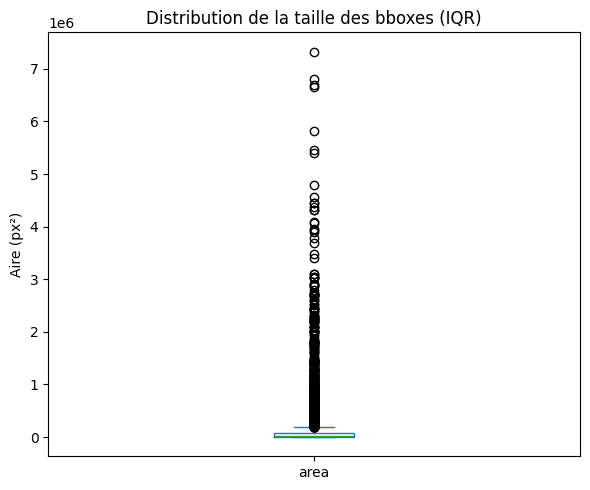

Etude interquartile de la distribution des bounding boxes des dechets:
count    4.784000e+03
mean     1.504072e+05
std      4.850848e+05
min      5.550000e+01
25%      2.142000e+03
50%      1.424475e+04
75%      7.533312e+04
max      7.328036e+06
Name: area, dtype: float64


In [ ]:
# Etude de l'aire des bounding boxes englobant les dechets

df["area"].plot(kind="box", figsize=(6, 5)) # Boxplot
plt.ylabel("Aire (px²)")
plt.title("Distribution de la taille des bboxes (IQR)")
plt.tight_layout()
plt.show()

print("Etude interquartile de la distribution des bounding boxes des dechets:")
print(df["area"].describe())

Maintenant, le but du boxplot au dessus est de faire une etude de l'aire des bounding boxes englobant les dechets. En gros, la plupart sont proches et similaires (globalement entre 0 et 4 la plupart), sauf quelques gros outliers. Aussi, si on voit l'etude interquartile de la distribution, on voit que 2142 boxes sont au dessous de Q1 (25%), et c'est la moitie presque, ce qui vraiment montre que les aires sont proches et similaires.


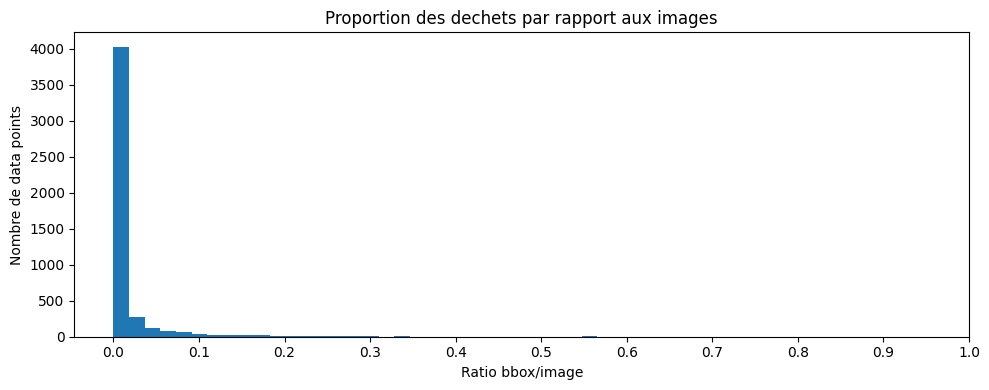

Etude de la distribution des bounding boxes par rapport aux images en entier:
count    4784.000000
mean        0.015843
std         0.046928
min         0.000007
25%         0.000259
50%         0.001759
75%         0.008839
max         0.912481
Name: bbox_ratio, dtype: float64


In [ ]:
# Etude du ratio des bounding boxes par rapport aux images en entier

df["img_area"] = df["img_width"] * df["img_height"]
df["bbox_ratio"] = df["area"] / df["img_area"]
# Un ratio proche de 0 veut dire que le dechet est trops petit, mais proche de 1 veut dire occupe presque toute l'image

df["bbox_ratio"].plot(kind="hist", bins=50, figsize=(10, 4)) # Histogramme
plt.xlabel("Ratio bbox/image")
plt.ylabel("Nombre de data points")
plt.xticks(np.arange(0, 1.1, 0.1))
plt.title("Proportion des dechets par rapport aux images")
plt.tight_layout()
plt.show()

print("Etude de la distribution des bounding boxes par rapport aux images en entier:")
print(df["bbox_ratio"].describe())

Ici, on etudie le pourcentage d'image que les bounding boxes des dechets occuppent (0 ca veut dire dechets petits, 1 ca veut dire dechets trops grands en ratio de taille). On remarque que la plupart ont une faible ratio, donc les dechets sont relativement petits.

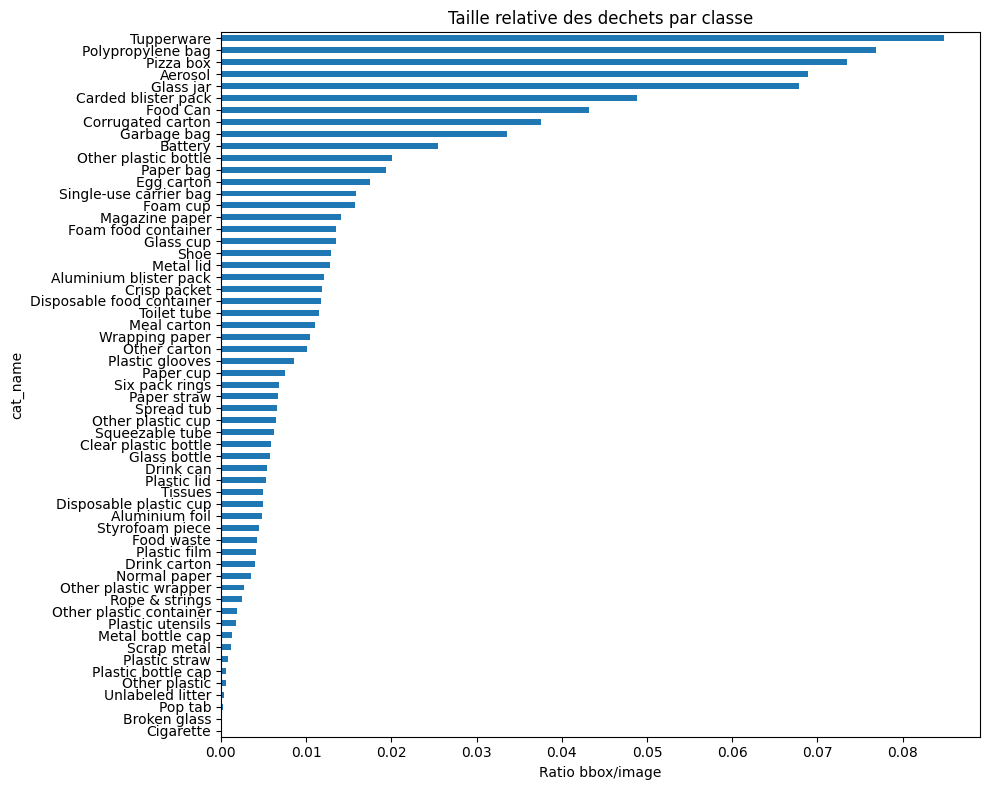

In [ ]:
# Etude de la taille des bounding boxes par categorie de dechets

df.groupby("cat_name")["bbox_ratio"].median().sort_values().plot(kind="barh", figsize=(10, 8))
plt.xlabel("Ratio bbox/image")
plt.title("Taille relative des dechets par classe")
plt.tight_layout()
plt.show()

In [ ]:
# Maintenant, on veut voir la distribution des supercategories en se basant sur la frequence ET la taille relative des bboxs

sc_counts = df.groupby("supercategory").size().rename("count")

df["bbox_ratio"] = df["area"] / (df["img_width"] * df["img_height"])
sc_bbox = df.groupby("supercategory")["bbox_ratio"].mean().rename("avg_bbox_ratio")

summary = pd.concat([sc_counts, sc_bbox], axis=1)
summary["norm_count"] = summary["count"] / summary["count"].max()
summary["norm_bbox"] = summary["avg_bbox_ratio"] / summary["avg_bbox_ratio"].max()
summary["indicator"] = np.sqrt(summary["norm_count"] * summary["norm_bbox"])
summary = summary.sort_values("indicator", ascending=False)

summary["above_mean"] = summary["indicator"] > summary["indicator"].mean()
above_mean_sc = summary[summary["above_mean"]].index.to_numpy()

print(summary.round(4))
print(above_mean_sc)

                       count  avg_bbox_ratio  norm_count  norm_bbox  \
supercategory                                                         
Plastic bag & wrapper    850          0.0245      1.0000     0.3948   
Carton                   251          0.0482      0.2953     0.7777   
Bottle                   439          0.0267      0.5165     0.4310   
Can                      273          0.0218      0.3212     0.3512   
Cup                      192          0.0230      0.2259     0.3709   
Styrofoam piece          112          0.0349      0.1318     0.5630   
Paper                    148          0.0205      0.1741     0.3312   
Plastic container         72          0.0400      0.0847     0.6454   
Lid                       87          0.0235      0.1024     0.3789   
Paper bag                 27          0.0542      0.0318     0.8743   
Bottle cap               289          0.0048      0.3400     0.0777   
Unlabeled litter         517          0.0025      0.6082     0.0404   
Other 

In [ ]:
# Maintenant, on veut analyzer les 9 supercategories qui avaient un indicator superieur a la moyenne des indicators

sc_ind = ["Plastic bag & wrapper", "Carton", "Bottle", "Can", "Cup", "Styrofoam piece", "Paper", "Plastic container", "Lid"]

sc_df = df[df["supercategory"].isin(sc_ind)].copy()
objs_per_image = df.groupby("img_id").size()

results = []

for sc in sc_ind:

    rows = sc_df[sc_df["supercategory"] == sc]
    count = len(rows)

    img_sizes = rows["img_id"].map(objs_per_image)
    alone = (img_sizes == 1).sum()
    with_others = (img_sizes > 1).sum()

    pct_alone = alone / count * 100
    pct_with = with_others / count * 100

    avg_bbox = rows["bbox_ratio"].mean()

    multi_rows = rows[img_sizes > 1]

    if len(multi_rows) > 0:
        img_bbox_min = df.groupby("img_id")["bbox_ratio"].min()
        img_bbox_max = df.groupby("img_id")["bbox_ratio"].max()

        is_smallest = (multi_rows["bbox_ratio"] == multi_rows["img_id"].map(img_bbox_min)).sum()
        is_largest  = (multi_rows["bbox_ratio"] == multi_rows["img_id"].map(img_bbox_max)).sum()

        pct_smallest = is_smallest / len(multi_rows) * 100
        pct_largest  = is_largest  / len(multi_rows) * 100
    else:
        pct_smallest = float("nan")
        pct_largest  = float("nan")

    results.append({
        "supercategory":       sc,
        "count":               count,
        "pct_alone":           round(pct_alone, 1),
        "pct_with_others":     round(pct_with, 1),
        "avg_bbox_ratio":      round(avg_bbox, 4),
        "pct_smallest_in_img": round(pct_smallest, 1),
        "pct_largest_in_img":  round(pct_largest, 1),
    })

summary_sc = pd.DataFrame(results).set_index("supercategory")
print(summary_sc.to_string())

                       count  pct_alone  pct_with_others  avg_bbox_ratio  pct_smallest_in_img  pct_largest_in_img
supercategory                                                                                                    
Plastic bag & wrapper    850       21.6             78.4          0.0245                 16.4                30.8
Carton                   251       13.1             86.9          0.0482                 17.4                44.0
Bottle                   439       12.3             87.7          0.0267                  5.2                53.0
Can                      273       14.3             85.7          0.0218                  8.1                35.0
Cup                      192       21.9             78.1          0.0230                  6.7                48.0
Styrofoam piece          112       21.4             78.6          0.0349                 21.6                27.3
Paper                    148       13.5             86.5          0.0205                